# Digit Classification Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_digits = pd.read_csv('data/train.csv')
df_digits

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

### Approach 1: Fully Connected Neural Network

In [4]:
y = df_digits['label']
X = df_digits.drop(['label'], axis=1)


lb = LabelBinarizer()
lb.fit(y)
y = lb.transform(y)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7986 - loss: 0.6817 - val_accuracy: 0.9497 - val_loss: 0.1906
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9662 - loss: 0.1131 - val_accuracy: 0.9663 - val_loss: 0.1164
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9854 - loss: 0.0596 - val_accuracy: 0.9695 - val_loss: 0.1038
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9936 - loss: 0.0337 - val_accuracy: 0.9725 - val_loss: 0.0939
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9977 - loss: 0.0195 - val_accuracy: 0.9738 - val_loss: 0.0908
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9995 - loss: 0.0125 - val_accuracy: 0.9745 - val_loss: 0.0855
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9998 - loss: 0.0077 - val_accuracy: 0.9740 - val_loss: 0.0857
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 0.9760 - v

<Axes: title={'center': 'Accuracy'}>

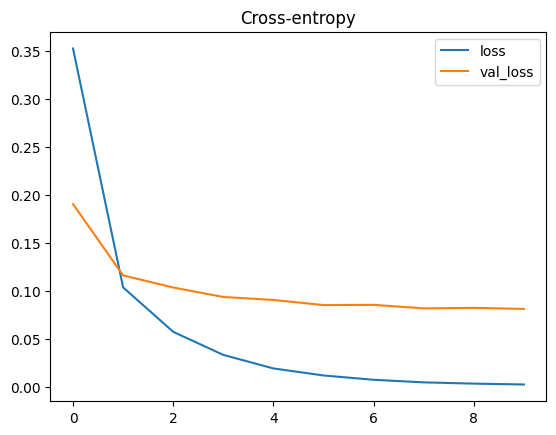

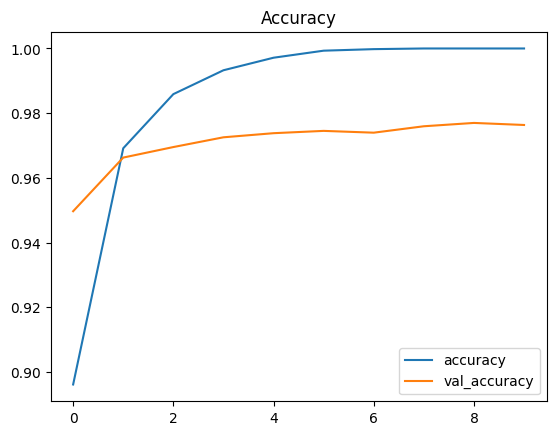

In [5]:
from tensorflow import keras
from tensorflow.keras import layers

conv_model = keras.Sequential([
    layers.Dense(units=784, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(10, activation='sigmoid')
])

conv_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    min_delta=0.01,
    restore_best_weights=True,
)

history = conv_model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=50,
    callbacks=[early_stopping],
)

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title="Cross-entropy", xlabel='Epoch', ylabel='Cross-Entropy')
history_df.loc[:, ['accuracy', 'val_accuracy']].plot(title="Accuracy", xlabel='Epoch', ylabel='Accuracy')

### Approach 2: Convolution Neural Network

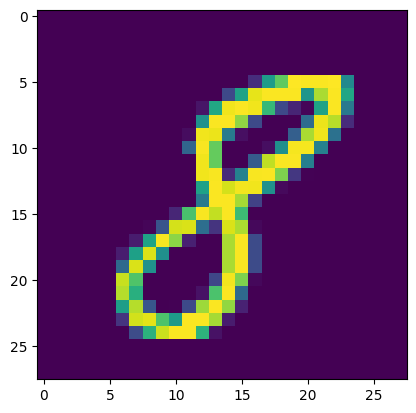

In [12]:
X_matrix = X.values.reshape(-1,28,28,1).astype('float32')/255.0
plt.imshow(X_matrix[30,:,:])


In [13]:
X_train, X_valid, y_train, y_valid = train_test_split(X_matrix, y, test_size=0.3, random_state=42, stratify=y)

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7117 - loss: 0.9296 - val_accuracy: 0.7264 - val_loss: 1.7364
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9570 - loss: 0.1692 - val_accuracy: 0.6106 - val_loss: 1.6700
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9728 - loss: 0.1098 - val_accuracy: 0.6394 - val_loss: 1.5306
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9822 - loss: 0.0761 - val_accuracy: 0.7190 - val_loss: 1.2771
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9872 - loss: 0.0577 - val_accuracy: 0.8125 - val_loss: 0.9729
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9903 - loss: 0.0467 - val_accuracy: 0.8569 - val_loss: 0.6612
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9933 - loss: 0.0360 - val_accuracy: 0.8937 - val_loss: 0.4317
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9954 - loss: 0.0280 - val_accuracy: 0.9581 - v

<Axes: title={'center': 'Accuracy'}>

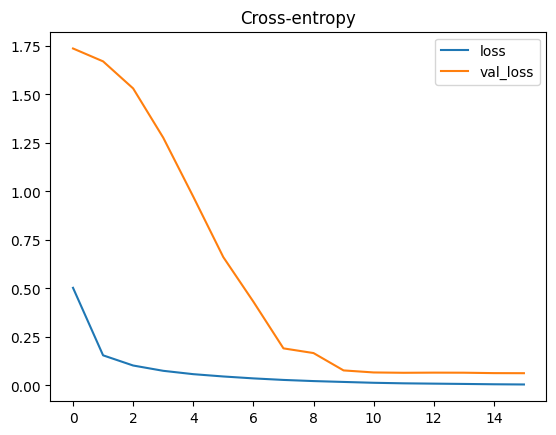

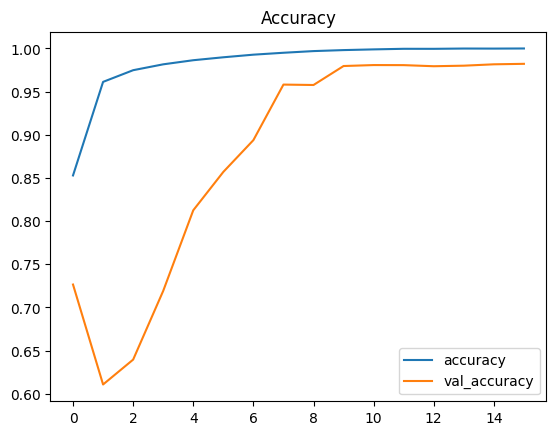

In [16]:
from tensorflow import keras
from tensorflow.keras import layers

conv_model = keras.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=2),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Flatten(),
    layers.Dense(units=64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(10, activation='sigmoid')
])

conv_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    min_delta=0.01,
    restore_best_weights=True,
)

history = conv_model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=50,
    callbacks=[early_stopping],
)

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title="Cross-entropy", xlabel='Epoch', ylabel='Cross-Entropy')
history_df.loc[:, ['accuracy', 'val_accuracy']].plot(title="Accuracy", xlabel='Epoch', ylabel='Accuracy')